In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d taruneshmehra/brain-tumor-datasets

Dataset URL: https://www.kaggle.com/datasets/taruneshmehra/brain-tumor-datasets
License(s): unknown
  0% 0.00/59.4M [00:00<?, ?B/s]
100% 59.4M/59.4M [00:00<00:00, 1.04GB/s]


In [ ]:
!unzip brain-tumor-datasets.zip -d brain-tumor-datasets

Streaming output truncated to the last 5000 lines.
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_32_jpg.rf.5092aa81838844298cf5439a7e6097c8.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_33_jpg.rf.67ee24000ca1d75b083d22336065374f.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_36_jpg.rf.752e7440f1da1b958527a1eb7845b278.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_44_jpg.rf.dd887c9acf88cefb4efc298657e77d07.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_47_jpg.rf.b4f847ac23543e28ede57927aa68cfa2.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_50_jpg.rf.f0058803c96ff3bb75013e386290231f.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_51_jpg.rf.d68020abd336b3610f86885039ed095e.txt  
  inflating: brain-tumor-datasets/train/labels/volume_48_slice_52_jpg.rf.18dbdbf9f0d14269fa195201c60c42ad.txt  
  inflating: brain-tumor-datasets/train/labels/volume

# Task
Assist the user in building a brain tumor detection system by providing guidance on the necessary steps, including dataset understanding, model selection, data preparation, training, evaluation, and potential deployment. The user has already downloaded the dataset using the Kaggle API.

## Understand the dataset

### Subtask:
Explore the structure of the downloaded dataset, including the image format, labels, and the distribution of tumor types (if applicable).


**Reasoning**:
List the contents of the downloaded dataset directory to understand the file structure.



In [ ]:
import os
# List the contents of the extracted directory
!ls brain-tumor-datasets/

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


**Reasoning**:
Explore the contents of the 'train' directory, which likely contains the training images and labels, and then inspect the file types within that directory to understand the image format and label format.



In [ ]:
# List the contents of the 'train' directory
!ls brain-tumor-datasets/train/

# Get a list of files in the 'images' and 'labels' directories to inspect file types
train_images_dir = 'brain-tumor-datasets/train/images/'
train_labels_dir = 'brain-tumor-datasets/train/labels/'

image_files = os.listdir(train_images_dir)
label_files = os.listdir(train_labels_dir)

print(f"First 5 image files in train: {image_files[:5]}")
print(f"First 5 label files in train: {label_files[:5]}")

images	labels
First 5 image files in train: ['volume_202_slice_49_jpg.rf.d6e612e4904d3368964e4e7a009c6c86.jpg', 'volume_19_slice_39_jpg.rf.d3907393cc106e6432b2662fd2dad0ce.jpg', 'volume_346_slice_97_jpg.rf.4ac79770edc092ec4feba6eac59e44c0.jpg', 'volume_368_slice_114_jpg.rf.6b57be9251a8e97ce98e2068b3d4bf45.jpg', 'volume_240_slice_35_jpg.rf.49e7ad4238e5b32c3575b3b1c2273541.jpg']
First 5 label files in train: ['volume_91_slice_116_jpg.rf.9d15417980321c4f1621d0e35854f686.txt', 'volume_161_slice_77_jpg.rf.73b2174b007b96e01966e8ce957d0619.txt', 'volume_46_slice_61_jpg.rf.3549b1a5593b593c6c92b39254a110d9.txt', 'volume_20_slice_51_jpg.rf.9c4130d10838d0cea1b8fd98ecb7d5d9.txt', 'volume_68_slice_65_jpg.rf.d497ea0f102080444fd32c3ef7f1be66.txt']


**Reasoning**:
The previous output shows that the images are in JPEG format and the labels are in text files. Now, inspect the content of a few label files to understand the label format and the information they contain, which will reveal the distribution of tumor types.



In [ ]:
# Read and print the content of a few label files
for i in range(3):
    label_file_path = os.path.join(train_labels_dir, label_files[i])
    with open(label_file_path, 'r') as f:
        content = f.read()
        print(f"Content of {label_files[i]}:\n{content}\n")

# Count the number of image and label files
num_image_files = len(image_files)
num_label_files = len(label_files)

print(f"Number of image files in train: {num_image_files}")
print(f"Number of label files in train: {num_label_files}")

# Assuming the label files contain class index as the first number,
# count the occurrences of each class.
class_counts = {}
for label_file in label_files:
    label_file_path = os.path.join(train_labels_dir, label_file)
    with open(label_file_path, 'r') as f:
        for line in f:
            class_index = int(line.split()[0])
            class_counts[class_index] = class_counts.get(class_index, 0) + 1

print("Distribution of tumor types (class counts):")
for class_index, count in class_counts.items():
    print(f"Class {class_index}: {count}")


Content of volume_91_slice_116_jpg.rf.9d15417980321c4f1621d0e35854f686.txt:
1 0.59375 0.6104166666666667 0.32083333333333336 0.1625

Content of volume_161_slice_77_jpg.rf.73b2174b007b96e01966e8ce957d0619.txt:
0 0.42916666666666664 0.4375 0.08333333333333333 0.075
1 0.41041666666666665 0.42291666666666666 0.17916666666666667 0.1625
2 0.42916666666666664 0.4354166666666667 0.09166666666666666 0.0875

Content of volume_46_slice_61_jpg.rf.3549b1a5593b593c6c92b39254a110d9.txt:
1 0.48541666666666666 0.5875 0.30416666666666664 0.175

Number of image files in train: 6930
Number of label files in train: 6930
Distribution of tumor types (class counts):
Class 1: 6753
Class 0: 4238
Class 2: 4058


## Choose a model

### Subtask:
Select a suitable machine learning model for image classification or object detection. Common choices include convolutional neural networks (CNNs) like VGG, ResNet, or YOLO.


## Prepare the data

### Subtask:
Preprocess the images for the chosen model. This may involve resizing, normalization, data augmentation, and splitting the data into training, validation, and test sets.


**Reasoning**:
I need to preprocess the images and labels for the YOLO model. This involves resizing images, normalizing pixel values, applying data augmentation, and transforming bounding box coordinates. I will use the `albumentations` library for data augmentation and image manipulation as it handles both image and bounding box transformations. I will also structure the data into a format suitable for YOLO training. Since the dataset is already split into train, validation, and test sets, I will process each set accordingly.



In [ ]:
import os
import cv2
import numpy as np
import albumentations as A

# Define the input size for the YOLO model (a common size is 640x640)
IMAGE_SIZE = 320

# Define augmentation pipeline for the training set
# Removed A.Normalize as YOLO will handle this internally.
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.6),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Define transformation pipeline for validation and test sets (only resizing)
# Removed A.Normalize as YOLO will handle this internally.
val_test_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def preprocess_data(data_dir, transform, output_dir):
    """Preprocesses
    Preprocesses images and labels in a given directory.

    Args:
        data_dir (str): Path to the input data directory (e.g., 'train', 'valid', 'test').
        transform (A.Compose): Albumentations transformation pipeline.
        output_dir (str): Path to the output directory to save preprocessed data.
    """
    image_dir = os.path.join(data_dir, 'images')
    label_dir = os.path.join(data_dir, 'labels')
    output_image_dir = os.path.join(output_dir, 'images')
    output_label_dir = os.path.join(output_dir, 'labels')

    os.makedirs(output_image_dir, exist_ok=True)
    os.makedirs(output_label_dir, exist_ok=True)

    image_files = os.listdir(image_dir)

    for image_file in image_files:
        image_path = os.path.join(image_dir, image_file)
        label_file = image_file.replace('.jpg', '.txt').replace('.jpeg', '.txt').replace('.png', '.txt')
        label_path = os.path.join(label_dir, label_file)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        bboxes = []
        class_labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    # YOLO format: class_id center_x center_y width height (normalized)
                    x_center, y_center, width, height = map(float, parts[1:])
                    bboxes.append([x_center, y_center, width, height])
                    class_labels.append(class_id)

        # Apply transforms without normalization
        transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
        transformed_image = transformed['image']
        transformed_bboxes = transformed['bboxes']
        transformed_class_labels = transformed['class_labels']

        # Ensure image is in 0-255 uint8 range for saving
        transformed_image = np.clip(transformed_image, 0, 255).astype(np.uint8)

        # Save the preprocessed image
        output_image_path = os.path.join(output_image_dir, image_file)
        cv2.imwrite(output_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))

        # Save the transformed labels
        output_label_path = os.path.join(output_label_dir, label_file)
        with open(output_label_path, 'w') as f:
            for bbox, class_label in zip(transformed_bboxes, transformed_class_labels):
                # Albumentations outputs YOLO format directly
                f.write(f"{class_label} {' '.join(map(str, bbox))}\n")

# Define input and output directories
base_data_dir = 'brain-tumor-datasets'
preprocessed_output_dir = 'preprocessed_brain_tumor_datasets'

# Preprocess training data
preprocess_data(os.path.join(base_data_dir, 'train'), train_transform, os.path.join(preprocessed_output_dir, 'train'))

# Preprocess validation data
preprocess_data(os.path.join(base_data_dir, 'valid'), val_test_transform, os.path.join(preprocessed_output_dir, 'valid'))

# Preprocess test data
preprocess_data(os.path.join(base_data_dir, 'test'), val_test_transform, os.path.join(preprocessed_output_dir, 'test'))

print("Preprocessing complete. Data saved to:", preprocessed_output_dir)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Preprocessing complete. Data saved to: preprocessed_brain_tumor_datasets


## Train the model

### Subtask:
Train the selected model on the prepared training data, monitoring its performance on the validation set.


**Reasoning**:
Import the necessary libraries for training a YOLO model and load a pre-trained YOLOv8 model from Ultralytics.



In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.1 MB/s eta 0:00:00


**Reasoning**:
Now that ultralytics is installed, import the necessary libraries and load the YOLO model.



In [ ]:
import torch
import os
from ultralytics import YOLO

# Load a pre-trained YOLOv8 model
model = YOLO('yolov8n.pt') # Using a nano model for demonstration

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Reasoning**:
Define the paths to the preprocessed datasets and train the YOLO model using the train() method, specifying the data configuration file and the number of epochs.



In [ ]:
# Define paths to the preprocessed datasets
train_data_dir = 'preprocessed_brain_tumor_datasets/train/images'
val_data_dir = 'preprocessed_brain_tumor_datasets/valid/images'

# Create a data.yaml file for YOLO
data_yaml_content = f"""
train: {train_data_dir}
val: {val_data_dir}
nc: 3  # number of classes
names: ['tumor', 'tumor_type_1', 'tumor_type_2']  # Replace with your actual class names
"""

with open('data.yaml', 'w') as f:
    f.write(data_yaml_content)

# Train the model
results = model.train(data='data.yaml', epochs=5) # Train for 3 epochs

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=T

## Evaluate the model

### Subtask:
Evaluate the trained model's performance on the test set using appropriate metrics (e.g., precision, recall, mAP) and visualize some predictions.

**Reasoning**:
Now that the model is trained, evaluate its performance on the test dataset. This will involve using the trained model to make predictions on the preprocessed test data and then calculating evaluation metrics such as Mean Average Precision (mAP), precision, and recall. Visualizing some predictions can also provide qualitative insights into the model's performance.

In [ ]:
# Evaluate the model on the test set
test_data_dir = 'preprocessed_brain_tumor_datasets/test/images'

# Create a data.yaml for test set evaluation
data_yaml_content_test = f"""
train: {train_data_dir}
val: {val_data_dir}
test: {test_data_dir}
nc: 3
names: ['tumor', 'tumor_type_1', 'tumor_type_2']
"""

with open('data_test.yaml', 'w') as f:
    f.write(data_yaml_content_test)

# Validate the best model on the test set
# The 'best.pt' model is typically saved in the 'runs/detect/trainX/weights/' directory
# where 'trainX' is the name of the latest training run (e.g., train6 from the previous output).
# You might need to adjust the path if your training run name is different.
# You can find the exact path in the output of the model.train() command.

best_model_path = '/content/runs/detect/train2/weights/best.pt' # Adjust if needed
loaded_model = YOLO(best_model_path)
metrics = loaded_model.val(data='data_test.yaml', split='test')

print("Test Metrics:")
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
print(f"Precision: {metrics.box.p}")
print(f"Recall: {metrics.box.r}")

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 8.4±1.5 MB/s, size: 13.6 KB)
val: Scanning /content/preprocessed_brain_tumor_datasets/test/labels... 990 images, 15 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 990/990 338.1it/s 2.9s
val: New cache created: /content/preprocessed_brain_tumor_datasets/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 3.7s/it 3:50
                   all        990       2106       0.74       0.55      0.609       0.32
                 tumor        588        588       0.72       0.42      0.492      0.226
          tumor_type_1        964        964      0.799      0.709      0.757      0.439
          tumor_type_2        554        554        0.7      0.522      0.579      0.295
Speed: 1.9ms preprocess, 224.1ms in

Displaying predictions for 3 random test images:
Processing image: preprocessed_brain_tumor_datasets/test/images/volume_71_slice_112_jpg.rf.b5754c3d1479b15c0f70b743a4c22b16.jpg

image 1/1 /content/preprocessed_brain_tumor_datasets/test/images/volume_71_slice_112_jpg.rf.b5754c3d1479b15c0f70b743a4c22b16.jpg: 640x640 1 tumor, 1 tumor_type_1, 1 tumor_type_2, 806.0ms
Speed: 92.3ms preprocess, 806.0ms inference, 10.2ms postprocess per image at shape (1, 3, 640, 640)


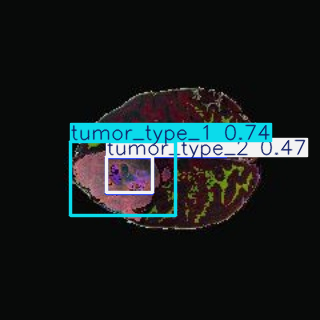

Processing image: preprocessed_brain_tumor_datasets/test/images/volume_8_slice_33_jpg.rf.4984abe90aaf538c98d7e24fd89c5d54.jpg

image 1/1 /content/preprocessed_brain_tumor_datasets/test/images/volume_8_slice_33_jpg.rf.4984abe90aaf538c98d7e24fd89c5d54.jpg: 640x640 1 tumor_type_1, 723.4ms
Speed: 23.3ms preprocess, 723.4ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)


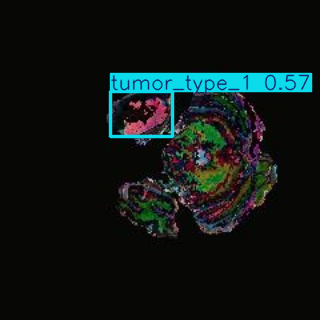

Processing image: preprocessed_brain_tumor_datasets/test/images/volume_221_slice_69_jpg.rf.059afe93684f0090e88ca8d790751176.jpg

image 1/1 /content/preprocessed_brain_tumor_datasets/test/images/volume_221_slice_69_jpg.rf.059afe93684f0090e88ca8d790751176.jpg: 640x640 1 tumor, 1 tumor_type_1, 1 tumor_type_2, 1330.2ms
Speed: 10.5ms preprocess, 1330.2ms inference, 11.4ms postprocess per image at shape (1, 3, 640, 640)


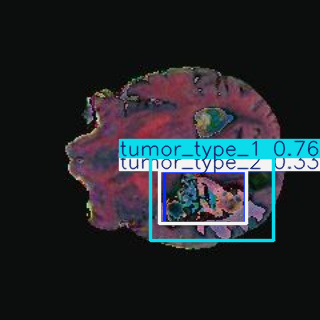

In [ ]:
import random
from PIL import Image

# Get a list of all test image paths
test_image_paths = [os.path.join(test_data_dir, f) for f in os.listdir(test_data_dir)]

# Select a few random images to visualize
num_images_to_display = 3
sample_image_paths = random.sample(test_image_paths, num_images_to_display)

print(f"Displaying predictions for {num_images_to_display} random test images:")
for image_path in sample_image_paths:
    print(f"Processing image: {image_path}")
    # Run inference on the image
    results = loaded_model(image_path)

    # Plot the results on the image
    for r in results:
        im_bgr = r.plot()
        display(Image.fromarray(im_bgr[..., ::-1]))

In [ ]:
!ls /content/runs/detect

train  train2  val


In [ ]:
!ls /content/runs/detect/train2/weights

best.pt  last.pt
